# GW170817 with HyperWave: from signal recovery to parameter estimation

**A student tutorial using real public H1 / L1 / V1 data.**

Learning goals: understand the PSD, recover a known signal with matched filtering,
connect the likelihood to Bayes' theorem, and distinguish a fast classroom PE
demonstration from a longer run that requires convergence checks.

The notebook, plots and companion scripts are designed to be used together in class.

The electromagnetic component adds real AT2017gfo light curves and a fast descriptive fit.

The final section performs **joint GW–EM sampling** using the real strain and early AT2017gfo photometry.

## 1. Choose a route

| Route | What it does | Runtime / limitation |
|---|---|---|
| `preview` | Displays a saved previous GW fast run | Immediate; no download or new sampling |
| `fast` (default) | Real data, 32 s, 64–512 Hz, TaylorF2, 4 free parameters | Sampling took a few seconds locally; total runtime is measured below |
| Full PE (separate cells) | 256 s, 23–1024 Hz, IMRPhenomPv2_NRTidal, 17 science parameters | May take hours or longer, depending on hardware and convergence |

The first data read downloads approximately 175 MiB of strain; download time depends on
your connection. The `fast` route restricts the information and dimensions; its posterior
is not equivalent to the full posterior. The `preview` route displays previous results
without performing new GW sampling. The optional light-curve section uses bundled observations and computes a short descriptive fit in either mode. Long runs are disabled by default in **Run All**.

## 2. Set up the environment

Run these commands once in a terminal, from the HyperWave repository root:

```bash
python3 -m venv .venv
.venv/bin/python -m pip install -c examples/real_event/gw170817-constraints.txt -e '.[plot]'
.venv/bin/python -m pip install jupyterlab ipykernel
.venv/bin/python -m ipykernel install --user --name hyperwave-tutorial --display-name 'HyperWave tutorial'
.venv/bin/jupyter lab examples/real_event/GW170817_tutorial.ipynb
```

In Jupyter, select the **HyperWave tutorial** kernel. The NumPy <2.4 constraint is
required for Eryn 1.2.6. This checkout also includes the import compatibility fix for
recent Matplotlib versions. The notebook does not install packages automatically.

In [1]:
import os, sys, json, time, subprocess
from pathlib import Path
from types import SimpleNamespace
from IPython.display import display, Image, Markdown

# Open the notebook from the repository root or from examples/real_event.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hyperwave').is_dir() and (p / 'pyproject.toml').exists()), None)
if ROOT is None:
    raise RuntimeError('Open the notebook inside the HyperWave checkout.')
os.chdir(ROOT)
EXAMPLES = ROOT / 'examples/real_event'
sys.path.insert(0, str(EXAMPLES))
print('Repository:', ROOT)
print('Python kernel:', sys.executable)

Repository: /Users/asasli/Documents/New project/HyperWave
Python kernel: /Users/asasli/Documents/New project/HyperWave/.venv/bin/python


In [2]:
# Change MODE to select the fast or preview route.
MODE = 'fast'             # 'fast' or 'preview'
RUN_FAST_SAMPLING = True
RUN_LIGHTCURVE = True     # bundled real photometry and a fast descriptive EM fit
RUN_FULL_SETUP = False    # optional full likelihood check
RUN_FULL_PE = False       # True only when you intend to start the long run
FAST_BURN, FAST_STEPS = 10, 20
FULL_BURN, FULL_STEPS = 1000, 1000  # initial budget, not a convergence certificate
FULL_LIKELIHOOD = 'gaussian'        # 'gaussian' or 'hyperbolic'
SEED = 170817
assert MODE in {'fast', 'preview'}
assert FULL_LIKELIHOOD in {'gaussian', 'hyperbolic'}

CACHE = ROOT / 'results/gw170817/data'
FAST_OUT = ROOT / 'results/gw170817_notebook_fast'
DEMO = EXAMPLES / 'gw170817_demo'
FAST_OUT.mkdir(parents=True, exist_ok=True)
ARTIFACTS = FAST_OUT if MODE == 'fast' else DEMO
timings = {}
RUN_JOINT_PE = True       # fast mode only: 8-parameter GW + early-photosphere diagnostic
JOINT_BURN, JOINT_STEPS = 10, 40
RUN_FULL_JOINT_PE = False # optional 21-parameter GW+EM run; hours or longer


## 3. Data and the PSD

We explicitly use the **cleaned GW170817 v2** release. Generic open-data fetching
can return data containing the Livingston glitch near coalescence.
We do not inject a synthetic signal: the signal is already in the real strain data.

The PSD $S_n(f)$ describes the noise power as a function of frequency. We estimate it
with median Welch averaging, 16 s Hann windows and 50% overlap, using 512 s before
the analysis segment. For the fast run, this interval avoids the signal **in the
selected 64–512 Hz band**. Starting at 64 Hz substantially reduces the inspiral
duration and the number of FFT bins. The fast run therefore loses low-frequency
information and high-frequency information relevant to tides.

[GWOSC: data release and usage notes](https://gwosc.org/events/GW170817/)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gw170817_pilot as pilot
# The standalone driver uses Agg; enable notebook plots here.
get_ipython().run_line_magic('matplotlib', 'inline')

if MODE == 'fast':
    started = time.perf_counter()
    gw, like, metadata = pilot.build(FAST_OUT, cache_dir=CACHE, **pilot.FAST_CONFIG)
    timings['data_and_psd_seconds'] = time.perf_counter() - started
    metadata['mode'] = 'classroom fast; conditional, reduced band'
    (FAST_OUT / 'manifest.json').write_text(json.dumps(metadata, indent=2))
else:
    metadata = json.loads((DEMO / 'manifest.json').read_text())
    print('Preview: using files from a previous Gaussian fast run.')

display(pd.DataFrame([{'duration_s': metadata['duration'], 'sample_rate_Hz': metadata['fs'],
                      'fmin_Hz': metadata['fmin'], 'fmax_Hz': metadata['fmax'],
                      'waveform': metadata['approximant']}]))

/Users/asasli/Documents/New project/HyperWave/.venv/lib/python3.11/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


> H1: fetching/reading cleaned v2 data


> L1: fetching/reading cleaned v2 data


> V1: fetching/reading cleaned v2 data


,duration_s,sample_rate_Hz,fmin_Hz,fmax_Hz,waveform
0,32,2048,64,512,TaylorF2


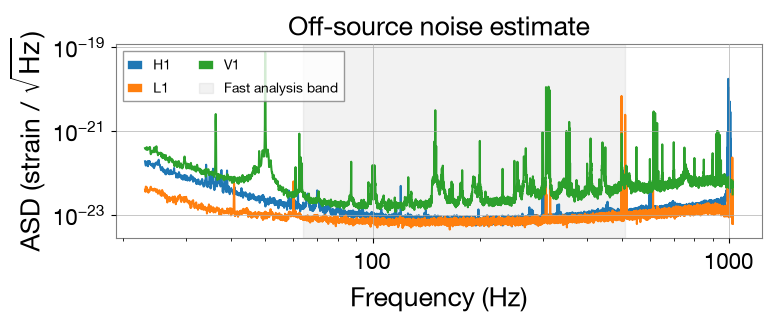

In [4]:
if MODE == 'fast':
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for ifo in gw.noise.ifos:
        model = ifo.power_spectral_density
        use = (model.frequency_array >= 23) & (model.frequency_array <= 1024)
        ax.loglog(model.frequency_array[use], np.sqrt(model.psd_array[use]), label=ifo.name)
    ax.axvspan(metadata['fmin'], metadata['fmax'], alpha=.1, color='grey', label='Fast analysis band')
    ax.set(xlabel='Frequency (Hz)', ylabel=r'ASD (strain / $\sqrt{\mathrm{Hz}}$)', title='Off-source noise estimate')
    ax.legend(fontsize=10, ncol=2); fig.tight_layout(); plt.show()
else:
    print('The live PSD plot is skipped in preview mode.')

## 4. Matched filtering: recover the known event

The noise-weighted inner product is
$$ (a|b)=4\,\mathrm{Re}\!\int_{f_{\min}}^{f_{\max}}
\frac{\tilde a(f)\tilde b^*(f)}{S_n(f)}\,df. $$
Matched filtering measures similarity between strain and a waveform template,
giving less weight to noisy frequencies. We take the absolute value of the complex
correlation to maximize over phase separately for each detector.

We scan 31 detector-frame chirp masses near the known event and a small time window.
The sum $\sqrt{\rho_{H1}^2+\rho_{L1}^2+\rho_{V1}^2}$ is an **incoherent targeted
statistic**. It does not reproduce the original search pipeline, the FAR, or a coherent search.

{
  "targeted_quadrature_snr": 27.091842927468235,
  "detector_frame_chirp_mass_grid": 1.1976,
  "lag_seconds": -0.00146484375,
  "significance": "not estimated; targeted recovery only"
}


{
  "conditional_best_fit": {
    "chirp_mass": 1.1974438274858141,
    "luminosity_distance": 46.62701773856358,
    "phase": 2.4826375664000153,
    "geocent_time": 1187008882.428647
  },
  "optimizer_success": false,
  "gaussian_log_likelihood": -55714.68077520865,
  "gaussian_log_likelihood_gain_vs_noise": 329.58530990039435
}


{'targeted_quadrature_snr': 27.091842927468235,
 'detector_frame_chirp_mass_grid': 1.1976,
 'lag_seconds': -0.00146484375,
 'significance': 'not estimated; targeted recovery only'}

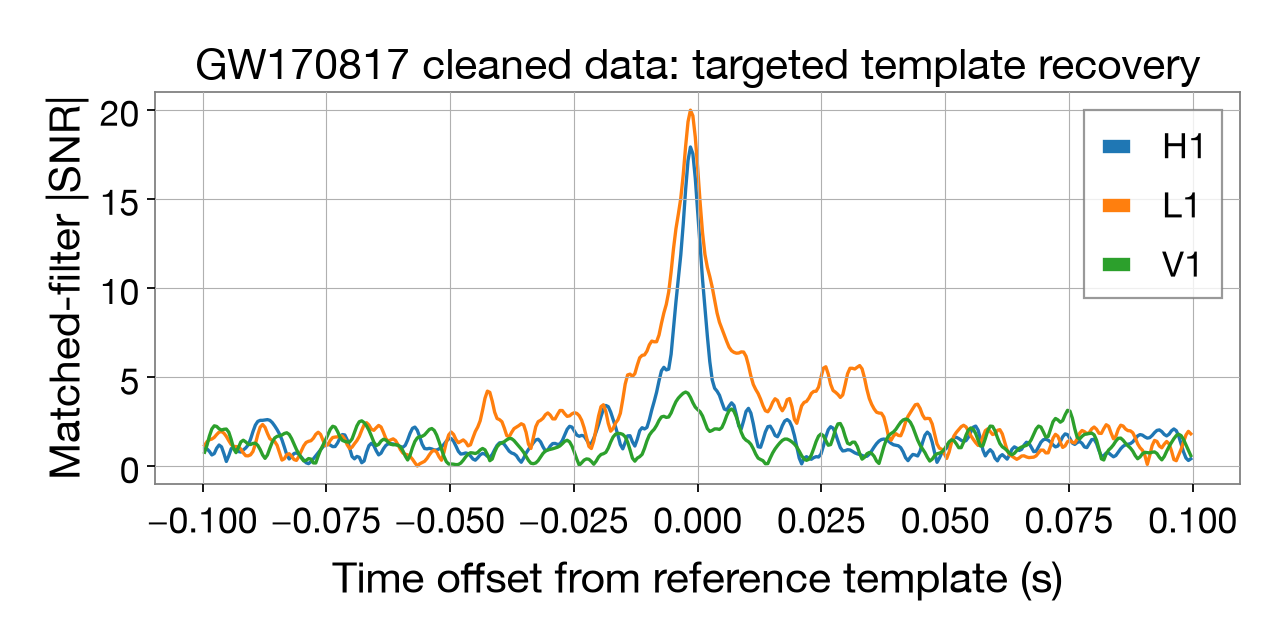

In [5]:
if MODE == 'fast':
    started = time.perf_counter()
    theta_fit = pilot.recover(gw, like, FAST_OUT)
    timings['recovery_and_fit_seconds'] = time.perf_counter() - started
recovery = json.loads((ARTIFACTS / 'recovery.json').read_text())
display(recovery)
display(Image(filename=str(ARTIFACTS / 'recovery.png'), width=850))

In the saved fast run, the statistic is approximately **27**, compared with approximately
**34** in the earlier 23–1024 Hz pilot. We do not expect identical SNR when the band,
template and PSD change. Small differences alone do not establish an error.

The chirp mass here is **detector-frame**. Converting to source-frame mass requires
redshift: $\mathcal M_{\rm det}=(1+z)\mathcal M_{\rm source}$.

## 5. From likelihood to posterior

For a fixed PSD, the Gaussian log likelihood is
$$\log\mathcal L(\theta)=-\tfrac12(d-h(\theta)|d-h(\theta))+\mathrm{const}.$$
Bayes' theorem gives $p(\theta|d)\propto\mathcal L(d|\theta)\,\pi(\theta)$.
The maximum-likelihood point is not the entire posterior.

The fast run varies only $\mathcal M_{\rm det}, d_L,\phi,t_c$.
We fix q, sky position, orientation, polarization, spins and tides.
The posterior is **conditional on these choices**, so its intervals may look
much narrower than those from full PE.

,parameter,minimum,maximum
0,chirp_mass,1.195000e+00,1.200000e+00
1,luminosity_distance,5.000000e+00,1.500000e+02
2,phase,0.000000e+00,6.283185e+00
3,geocent_time,1.187009e+09,1.187009e+09


,fixed parameter,value
0,mass_ratio,0.850000
1,ra,3.446160
2,dec,-0.408080
3,psi,0.000000
4,cos_theta_jn,0.921061
5,chi_1,0.000000
6,chi_2,0.000000
7,lambda_1,400.000000
8,lambda_2,400.000000


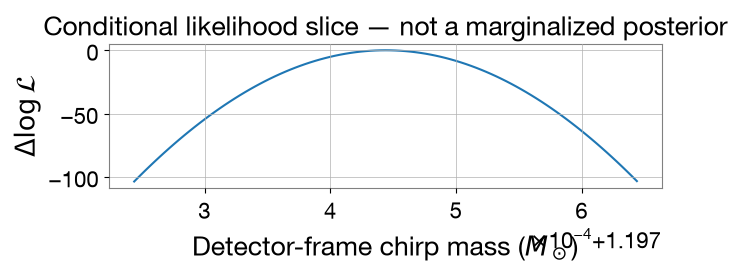

In [6]:
display(pd.DataFrame([{'parameter': name, 'minimum': bounds[0], 'maximum': bounds[1]}
                      for name, bounds in zip(pilot.NAMES, pilot.BOUNDS)]))
display(pd.DataFrame(list(pilot.FIXED.items()), columns=['fixed parameter', 'value']))

if MODE == 'fast':
    # A likelihood slice: all other parameters stay at the fitted values.
    masses = theta_fit[0] + np.linspace(-2e-4, 2e-4, 101)
    values = []
    for mass in masses:
        point = theta_fit.copy(); point[0] = mass
        values.append(float(like.gaussian(point)))
    values = np.array(values)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(masses, values-values.max())
    ax.set(xlabel=r'Detector-frame chirp mass ($M_\odot$)', ylabel=r'$\Delta\log\mathcal{L}$',
           title='Conditional likelihood slice — not a marginalized posterior')
    fig.tight_layout(); plt.show()

## 6. Fast PE with Eryn

Eryn uses walkers and parallel tempering. We initialize near the fit to demonstrate
a local region of high likelihood quickly. With **10 burn-in + 20 production steps**,
24 walkers and two temperatures, this is a short diagnostic.
Neither the initialization nor the run length establishes convergence or rules out
other posterior modes. Increasing the number of steps is an exercise, not a way
to select an arbitrary number that certifies the result.

> Running Eryn MCMC...


  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:03,  2.52it/s]

 20%|██        | 2/10 [00:00<00:02,  2.72it/s]

 30%|███       | 3/10 [00:01<00:02,  2.78it/s]

...

100%|██████████| 20/20 [00:06<00:00,  3.52it/s]

100%|██████████| 20/20 [00:06<00:00,  3.22it/s]

> Eryn sampling finished. Output at: /Users/asasli/Documents/New project/HyperWave/results/gw170817_notebook_fast/chains/gaussian_eryn.h5
Loading samples from /Users/asasli/Documents/New project/HyperWave/results/gw170817_notebook_fast/chains/gaussian_eryn.h5
480


Short conditional diagnostic; convergence not established; not LVK PE reproduction


,5%,median,95%
chirp_mass,1.197403e+00,1.197453e+00,1.197497e+00
luminosity_distance,4.420390e+01,4.665570e+01,4.801444e+01
phase,2.401132e+00,2.487804e+00,2.575492e+00
geocent_time,1.187009e+09,1.187009e+09,1.187009e+09


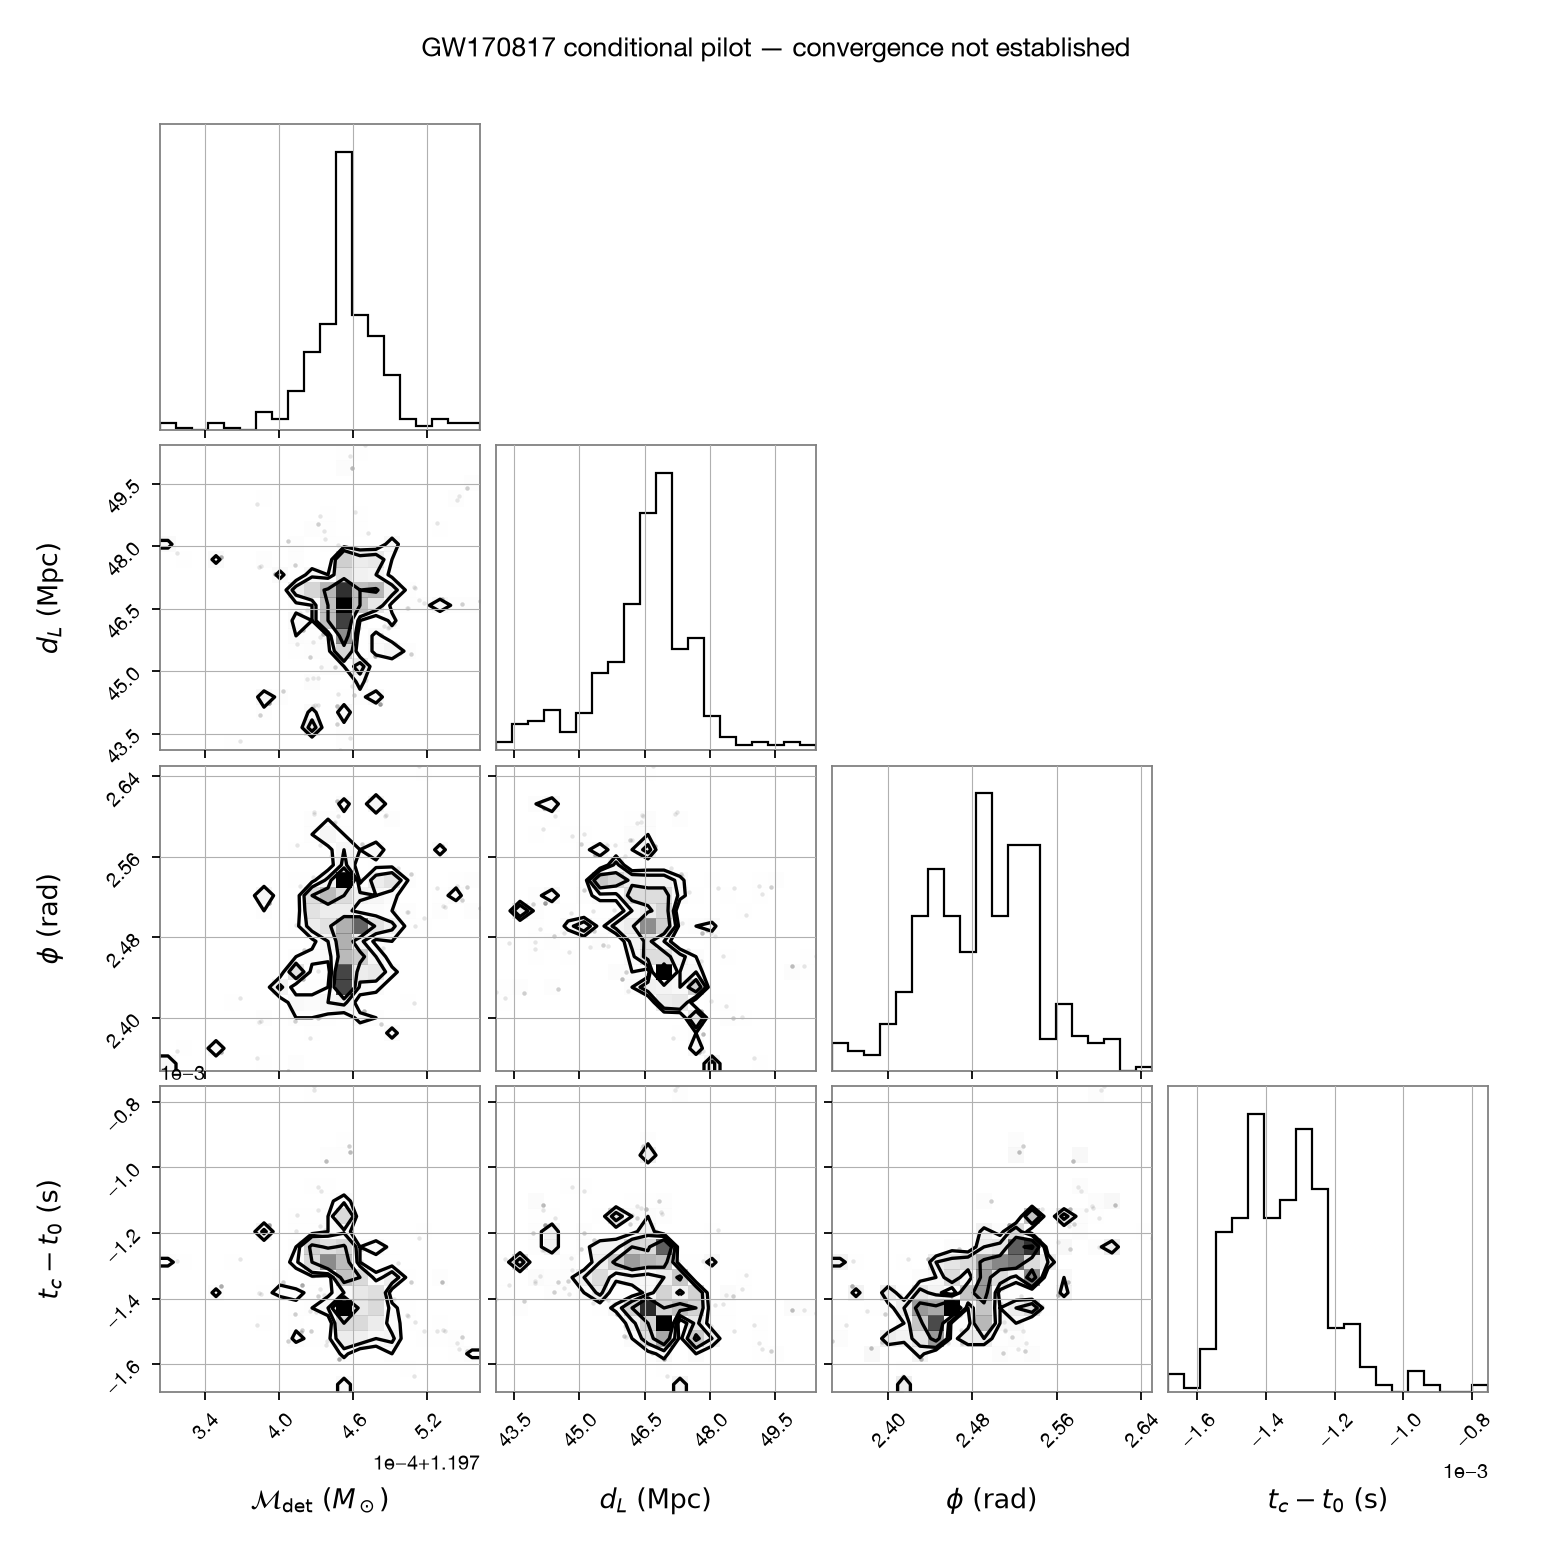

In [7]:
if MODE == 'fast' and RUN_FAST_SAMPLING:
    started = time.perf_counter()
    args = SimpleNamespace(seed=SEED, likelihood='gaussian', outdir=FAST_OUT,
                           burn=FAST_BURN, steps=FAST_STEPS)
    pilot.sample(like, theta_fit, args)
    timings['sampling_and_corner_seconds'] = time.perf_counter() - started
elif MODE == 'fast':
    print('Sampling is disabled; an old posterior is not loaded automatically.')

SHOW_POSTERIOR = MODE == 'preview' or RUN_FAST_SAMPLING
if SHOW_POSTERIOR:
    summary = json.loads((ARTIFACTS / 'pilot_quantiles.json').read_text())
    print(summary['warning'])
    display(pd.DataFrame(summary['quantiles_5_50_95'], index=['5%', 'median', '95%']).T)
    display(Image(filename=str(ARTIFACTS / 'pilot_corner.png'), width=800))

## 7. Chain diagnostics: many draws do not mean many independent samples

The traces below show five cold-chain walkers. Autocorrelation reduces the effective
sample size (ESS). A chain that is too short for a reliable autocorrelation-time
estimate must be reported as such.
Independent runs, mixing between modes and stable summaries are also needed.

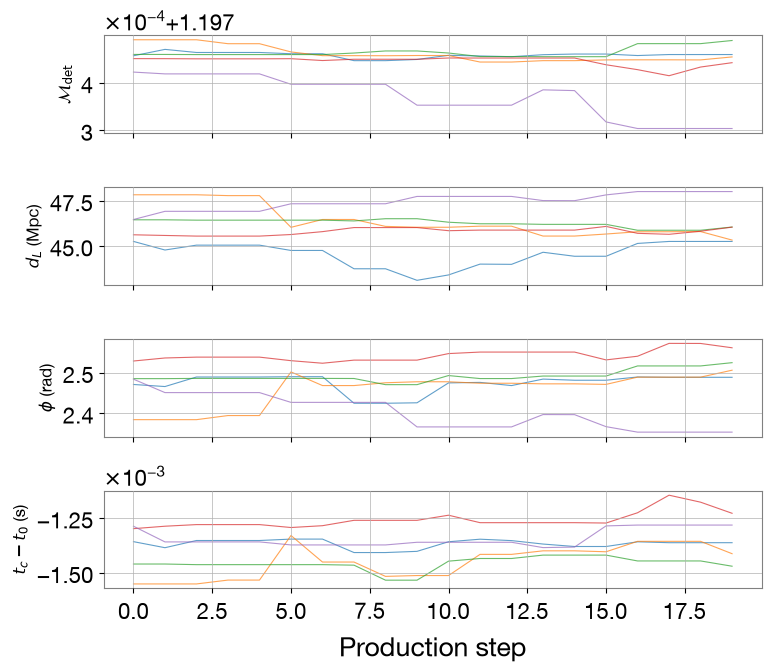

The chain is too short for a reliable tau / ESS estimate. Convergence has not been established.


In [8]:
if MODE == 'fast' and RUN_FAST_SAMPLING:
    from eryn.backends import HDFBackend
    from emcee.autocorr import integrated_time, AutocorrError
    backend = HDFBackend(str(FAST_OUT / 'chains/gaussian_eryn.h5'), read_only=True)
    chain = backend.get_chain()['model_0'][:, 0, :, 0, :]  # step, walker, parameter; cold temperature
    plot_chain = chain.copy(); plot_chain[:, :, 3] -= pilot.TC
    fig, axes = plt.subplots(4, 1, figsize=(8, 7), sharex=True)
    trace_labels = [r'$\mathcal{M}_{\rm det}$', r'$d_L$ (Mpc)', r'$\phi$ (rad)', r'$t_c-t_0$ (s)']
    for j, ax in enumerate(axes):
        ax.plot(plot_chain[:, :5, j], alpha=.7, linewidth=.8)
        ax.set_ylabel(trace_labels[j], fontsize=12)
    axes[-1].set_xlabel('Production step'); fig.tight_layout(); plt.show()
    try:
        tau = integrated_time(chain, tol=50, quiet=False)
        print('Estimated tau:', tau)
        print('This estimate alone does not establish mixing or convergence.')
    except AutocorrError:
        print('The chain is too short for a reliable tau / ESS estimate. Convergence has not been established.')
else:
    print('Chain diagnostics require a new live sampling run.')

## 8. Gaussian and hyperbolic likelihoods

HyperWave's hyperbolic likelihood allows heavier residual tails. This parameterization
adds one alpha and four delta parameters, one delta per frequency segment.
These are noise nuisance parameters, not tidal parameters.
A finite likelihood check verifies that the calculation works; it does not establish
that the hyperbolic method successfully handles this particular glitch.

Absolute log likelihoods from different models **are not sufficient for a Bayes factor**:
we need evidence, consistent normalization and integration over the corresponding priors.

In [9]:
if MODE == 'fast':
    gaussian_check = float(like.gaussian(theta_fit))
    hyperbolic_check = float(like.hyperbolic_classic(np.r_[theta_fit, 5., 5., 5., 5., 5.]))
    assert np.isfinite(gaussian_check) and np.isfinite(hyperbolic_check)
    print('Finite checks passed. Do not compare these two values as evidence.')
display(timings if MODE == 'fast' else {'mode': 'saved preview; no new timing'})

Finite checks passed. Do not compare these two values as evidence.


{'data_and_psd_seconds': 1.6785297919996083,
 'recovery_and_fit_seconds': 16.045300624798983,
 'sampling_and_corner_seconds': 10.571672917110845}

## 9. Full PE: release the remaining parameters

The larger driver has 17 science parameters, including q, sky position, inclination,
polarization, two spin magnitudes and directions, and $\lambda_1$, $\lambda_2$.
Defaults: **256 s, 4096 Hz sampling, 23–1024 Hz**, **IMRPhenomPv2_NRTidal**,
spin magnitudes 0–0.05, isotropic directions and sky, independent uniform tides
0–5000, and a Euclidean-volume distance prior from 5 to 100 Mpc.
The hyperbolic version adds five nuisance parameters, for a total of 22.

This releases the parameters in this configuration, but it remains a **reanalysis
configuration**: it does not exactly replicate every LVK prior, waveform, band,
calibration treatment or data product. Calibration is fixed at the nominal response.
The default 1000+1000 steps are an initial budget, not a convergence guarantee.
Prior initialization may take much longer than the fast run's warm start.

In [10]:
import gw170817_pe as full
science_priors = full.priors()
display(pd.DataFrame([{'parameter': k, 'prior': repr(v)} for k, v in science_priors.items()]))
print('Science dimensions:', len(science_priors))

,parameter,prior
0,chirp_mass,"Uniform(minimum=1.18, maximum=1.22, name='chir..."
1,mass_ratio,"Uniform(minimum=0.5, maximum=1.0, name='mass_r..."
2,psi,"Uniform(minimum=0, maximum=3.141592653589793, ..."
3,phase,"Uniform(minimum=0, maximum=6.283185307179586, ..."
4,ra,"Uniform(minimum=0, maximum=6.283185307179586, ..."
5,a_1,"Uniform(minimum=0, maximum=0.05, name='a_1', l..."
6,a_2,"Uniform(minimum=0, maximum=0.05, name='a_2', l..."
7,cos_theta_jn,"Uniform(minimum=-1, maximum=1, name='cos_theta..."
8,cos_tilt_1,"Uniform(minimum=-1, maximum=1, name='cos_tilt_..."
9,cos_tilt_2,"Uniform(minimum=-1, maximum=1, name='cos_tilt_..."


Science dimensions: 17


### Optional full setup without sampling

Set `RUN_FULL_SETUP=True` in the configuration cell and rerun the next cell.
It checks the likelihood for the larger configuration and writes a manifest.
To use a different model, change `FULL_LIKELIHOOD` and keep separate outputs.

In [11]:
FULL_OUT = ROOT / 'results' / f'gw170817_notebook_full_{FULL_LIKELIHOOD}_01'
full_command = [sys.executable, str(EXAMPLES / 'gw170817_pe.py'),
                '--likelihood', FULL_LIKELIHOOD, '--outdir', str(FULL_OUT)]
if RUN_FULL_SETUP:
    completed = subprocess.run(full_command, cwd=ROOT, check=True, capture_output=True, text=True)
    print(completed.stdout)
else:
    print('Full setup skipped. Set RUN_FULL_SETUP=True to enable.')

Full setup skipped. Set RUN_FULL_SETUP=True to enable.


### Long full sampling: enable separately

Set `RUN_FULL_PE=True` when you have time and a suitable machine.
With 64 walkers × 4 temperatures and an expensive BNS waveform, the run may take
hours or longer. Actual time depends on the evaluations and hardware; the fast
runtime cannot be transferred directly to a full run.

On a remote server, use the same script and environment. A notebook kernel that
may disconnect is not a reliable way to manage an unattended long run.
Change the output name before starting a new run to preserve previous chains.

In [12]:
long_command = full_command + ['--sample', '--burn', str(FULL_BURN), '--steps', str(FULL_STEPS),
                               '--walkers', '64', '--temperatures', '4', '--seed', str(SEED)]
if RUN_FULL_PE:
    chain_file = FULL_OUT / 'chains' / f'{FULL_LIKELIHOOD}_eryn.h5'
    if chain_file.exists():
        raise FileExistsError('A chain already exists. Choose a new FULL_OUT before starting another sampling run.')
    subprocess.run(long_command, cwd=ROOT, check=True)
else:
    print('Full PE skipped. Command for an explicitly enabled long run:')
    print(' '.join(long_command))

Full PE skipped. Command for an explicitly enabled long run:
/Users/asasli/Documents/New project/HyperWave/.venv/bin/python /Users/asasli/Documents/New project/HyperWave/examples/real_event/gw170817_pe.py --likelihood gaussian --outdir /Users/asasli/Documents/New project/HyperWave/results/gw170817_notebook_full_gaussian_01 --sample --burn 1000 --steps 1000 --walkers 64 --temperatures 4 --seed 170817


### After the full run

Analyze the cold chain **with its time structure**, not just flattened samples.npy:
trace plots, reliable autocorrelation/ESS estimates, multiple independent seeds,
stable summaries in longer runs, mixing and posterior predictive residuals.
R-hat requires suitable independent chains; ensemble walkers should not automatically
be treated as independent runs.

Comparison with published posteriors is meaningful after matching the data release,
priors, waveform, band and calibration. Discovery significance requires a search
and background analysis, not this tutorial's targeted SNR.

In [13]:
if (FULL_OUT / 'samples.npy').exists():
    full_samples = np.load(FULL_OUT / 'samples.npy')
    print('Saved draws / dimensions:', full_samples.shape)
    print('Draw count is not ESS; inspect the HDF chain before quoting intervals.')
else:
    print('No full sampling output exists. This is expected for the default Run All.')

No full sampling output exists. This is expected for the default Run All.


## 10. Electromagnetic component: the AT2017gfo light curve

AT2017gfo is the optical/near-infrared counterpart associated with GW170817.
The bundled file contains **real observational photometry**, copied without modification
from a pinned [NMMA example data file](https://github.com/nuclear-multimessenger-astronomy/nmma/blob/b62084fa0f59faae0b9bccc4ac63fe46a232e836/example_files/lightcurves/AT2017gfo.dat).
The URL, repository commit and SHA256 are in `at2017gfo_data/provenance.json`.
No NMMA installation, model download or network access is required for this section.

We retain native filter names and supplied magnitudes. We apply **no additional
extinction, zero-point, K-correction or bolometric conversion**. This is the explicit
`AT2017gfo.dat` variant, not the separately supplied `AT2017gfo_corrected.dat`.
Interpret the plots as observed brightness evolution, not intrinsic luminosity.
Check calibration conventions before deriving cross-system colors or fluxes.

There are 141 rows in nine filters. NMMA represents flux upper limits using infinite
magnitude uncertainties ([likelihood convention](https://github.com/nuclear-multimessenger-astronomy/nmma/blob/b62084fa0f59faae0b9bccc4ac63fe46a232e836/nmma/em/em_likelihood.py)).
We flag these rows, display them separately, and exclude them from the simple Gaussian fit.

References: [Pang et al., NMMA](https://arxiv.org/abs/2205.08513),
[Villar et al., combined AT2017gfo light curves](https://arxiv.org/abs/1710.11576).

In [14]:
import at2017gfo_lightcurve as em
if RUN_LIGHTCURVE:
    em_started = time.perf_counter()
    photometry, em_provenance = em.load_photometry(gps_time=pilot.TC)
    display(photometry.head())
    display(photometry.groupby('band').agg(rows=('magnitude', 'size'),
                                         upper_limits=('is_upper_limit', 'sum')))
    print('Source:', em_provenance['source_url'])
    print('SHA256 verified:', em_provenance['sha256'])
else:
    print('Light-curve section skipped. Set RUN_LIGHTCURVE=True to enable.')

,utc,band,magnitude,sigma_mag,mjd_utc,time_days,is_upper_limit
0,2017-08-18T00:00:00.000,2massh,18.26,0.15,57983.0,0.471477,False
1,2017-08-18T00:00:00.000,2massj,17.88,0.03,57983.0,0.471477,False
2,2017-08-18T00:00:00.000,2massks,18.62,0.11,57983.0,0.471477,False
3,2017-08-18T00:00:00.000,ps1::g,17.41,0.02,57983.0,0.471477,False
4,2017-08-18T00:00:00.000,ps1::i,17.48,0.03,57983.0,0.471477,False


,rows,upper_limits
band,,
2massh,17,0
2massj,14,0
2massks,23,0
ps1::g,13,0
ps1::i,20,1
ps1::r,19,0
ps1::y,15,1
ps1::z,18,0
sdssu,2,1


Source: https://raw.githubusercontent.com/nuclear-multimessenger-astronomy/nmma/b62084fa0f59faae0b9bccc4ac63fe46a232e836/example_files/lightcurves/AT2017gfo.dat
SHA256 verified: 368ab3a605455059672caaf6e1081a7a24573664d8253c6cf53e6054a9b56bd7


### Put EM and GW observations on the same clock

Photometry timestamps are UTC; the GW reference is GPS time. Convert the GPS epoch to
UTC MJD before taking a difference:
$$t_{\rm obs}=\mathrm{MJD}_{\rm UTC,phot}-\mathrm{MJD}_{\rm UTC,merger}.$$
These are **observer-frame days**. Source-frame times would require division by $(1+z)$.
Do not subtract GPS seconds directly from MJD or ignore the GPS–UTC offset.

In [15]:
if RUN_LIGHTCURVE:
    from astropy.time import Time
    merger_utc = Time(pilot.TC, format='gps').utc
    print('GW reference UTC:', merger_utc.isot)
    print('GW reference MJD UTC:', merger_utc.mjd)
    print('Photometry phase range (observer-frame days):',
          photometry.time_days.min(), photometry.time_days.max())

GW reference UTC: 2017-08-17T12:41:04.430
GW reference MJD UTC: 57982.52852349537
Photometry phase range (observer-frame days): 0.47147650463011814 25.44047650462744


### A fast descriptive fit, not a physical ejecta model

For each optical band, fit the detections between **1 and 5 observer-frame days**:
$$m_b(t)=a_b+b_b\log_{10}(t/1\,\mathrm{day}).$$
Within a fixed band and zero point, this corresponds to $F_{\nu,b}\propto t^{-\alpha_b}$,
with $\alpha_b=b_b/2.5$. Different slopes and residuals illustrate why a single decline
law need not describe every band or epoch. This slope is **not a radioactive-heating
index**, and the fit does not infer ejecta mass, opacity, temperature or an EOS.

We use independent magnitude errors with an **illustrative fixed 0.15 mag systematic floor**:
$\sigma_{\rm eff}^2=\sigma_m^2+0.15^2$. This floor is not inferred. Reported slope errors
are formal Gaussian errors under the assumed model; a poor reduced chi-square highlights
model mismatch. Upper limits require a censored-data likelihood for physical inference;
we do not silently count them as detections or assign an arbitrary detection error.

,band,n_points,magnitude_at_1day,slope_mag_per_dex,alpha,alpha_formal_sigma,reduced_chi2,fit_start_days,fit_end_days,systematic_mag
0,ps1::g,8,17.487565,6.629038,2.651615,0.169055,0.261775,1.0,5.0,0.15
1,ps1::r,10,17.259961,4.776902,1.910761,0.119251,0.628905,1.0,5.0,0.15
2,ps1::i,10,17.218725,3.324766,1.329907,0.144629,0.681861,1.0,5.0,0.15
3,ps1::z,9,17.239318,2.661373,1.064549,0.149986,0.779831,1.0,5.0,0.15


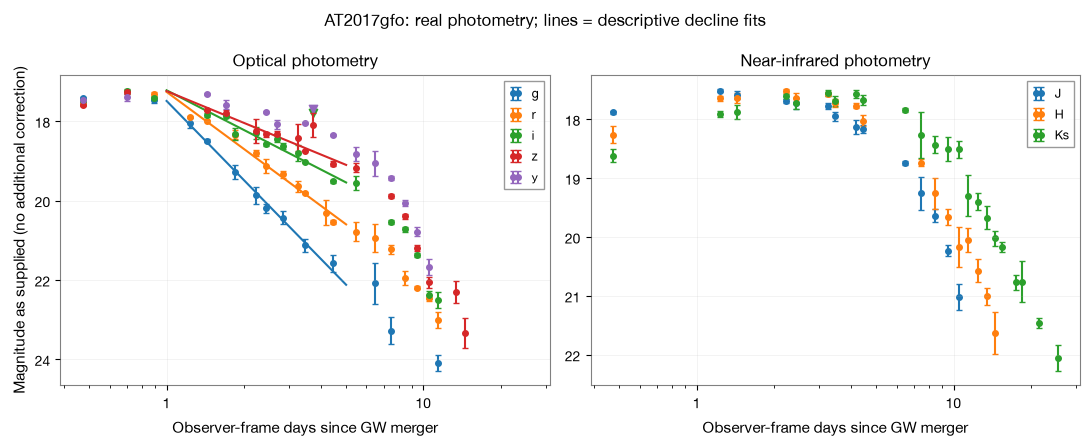

Downward triangles indicate flux upper limits: the source is fainter than the magnitude shown.
Light-curve section runtime (including displayed tables): 0.57 s


In [16]:
if RUN_LIGHTCURVE:
    EM_FIT_START, EM_FIT_END = 1.0, 5.0
    EM_SYSTEMATIC_MAG = 0.15
    em_fits = em.fit_decline(photometry, tmin=EM_FIT_START, tmax=EM_FIT_END,
                             systematic_mag=EM_SYSTEMATIC_MAG)
    display(em_fits)
    EM_OUT = ROOT / 'results/at2017gfo_notebook'
    em.plot_photometry(photometry, em_fits, outdir=EM_OUT)
    plt.show()
    em_fits.to_csv(EM_OUT / 'decline_fits.csv', index=False)
    print('Downward triangles indicate flux upper limits: the source is fainter than the magnitude shown.')
    timings['lightcurve_seconds'] = time.perf_counter() - em_started
    print('Light-curve section runtime (including displayed tables):', round(timings['lightcurve_seconds'], 2), 's')

## 11. Executable joint GW–EM parameter estimation

We now sample **one posterior using both datasets**, conditional on the association
of GW170817 with AT2017gfo. For independent instrument noise,
$$p(\theta_{\rm GW},\theta_{\rm EM}\mid d_{\rm GW},d_{\rm EM})\propto
\mathcal L_{\rm GW}\mathcal L_{\rm EM}\,\pi(\theta_{\rm GW},\theta_{\rm EM}).$$
Distance $D_L$ and merger time $t_c$ occur only once in the parameter vector.
The GW term is the strain likelihood, **not an already-prior-weighted GW posterior**.
Eryn applies the joint prior once. The earlier GW fit supplies an initial position only.

### A fast, explicit EM forward model

Use a spherical, cooling blackbody photosphere, motivated by early SED fits
([Cowperthwaite et al. 2017](https://arxiv.org/abs/1710.05840)):
$$R(t_r)=R_1(t_r/{\rm day})^{a_R},\qquad
T(t_r)=T_1(t_r/{\rm day})^{-a_T},\qquad
 t_r=\frac{t_{\rm obs}-(t_c-t_0)/86400}{1+z}.$$
Here $t_{\rm obs}$ is measured in days relative to the reference merger epoch.
We fix $z=0.0098$ ([host redshift](https://arxiv.org/abs/1710.05459)); we do not
convert this into a cosmological distance prior. The spectral prediction is
$$f_{\nu_o}=(1+z)\pi\frac{R^2}{D_L^2} B_{(1+z)\nu_o}(T)
10^{-0.4 A(\lambda_o)}.$$
Photon-counting band averages use $\langle f_\nu\rangle_b=
\int f_\nu T_b(\lambda)d\lambda/\lambda\,/\,
\int T_b(\lambda)d\lambda/\lambda$, and
$m_b=-2.5\log_{10}(\langle f_\nu\rangle_b/3631\,{\rm Jy})$.
The bundled, checksum-verified grizy throughput curves are sampled from
[SNCosmo's PS1 filters](https://sncosmo.readthedocs.io/en/stable/bandpass-list.html).
They avoid any new filter/model download during class.

The [NMMA data format](https://nuclear-multimessenger-astronomy.github.io/nmma/data_inj_obs.html)
specifies **AB magnitudes**. We use the unmodified `AT2017gfo.dat` input,
interpreting it as observed photometry. We attenuate the model with a fixed
Fitzpatrick (1999) law, $R_V=3.1$, $E(B-V)=0.105$; this is an explicit foreground
assumption consistent with [published AT2017gfo analyses](https://inspirehep.net/files/46a82da2dd413a5ea0085198e411b054).
Do not apply this attenuation again to already dereddened input. The compiled
filter labels are adopted literally; heterogeneous instrument calibration and
host extinction are not modeled.

Only **grizy detections from 0.4–2.5 observer-frame days** enter this EM likelihood.
The NIR, later data and upper limits remain in the earlier observational plot,
but do not enter this restricted early-photosphere fit. With a fixed illustrative
model-error floor $s=0.20$ mag, independent Gaussian magnitude errors give
$$\log\mathcal L_{\rm EM}=-\frac12\sum_i
\left[\frac{(m_i-m_i^{\rm model})^2}{\sigma_i^2+s^2}
+\log(2\pi(\sigma_i^2+s^2))\right].$$
The floor is assumed, not measured; correlations and calibration uncertainty
are omitted. Inspect residuals and vary the time window, dust and floor.

### What this model can and cannot teach

The fast parameter vector has **4 GW + 4 EM parameters**. GW mass ratio,
orientation, spins, tides and sky remain fixed as before. Uniform EM priors:
$\log_{10}(R_1/{\rm cm})\in[14,15.7]$,
$\log_{10}(T_1/{\rm K})\in[3.5,4.3]$, and $a_R,a_T\in[0,1.5]$.
The prior on log radius is a log-uniform radius prior, not a uniform one.

Photometry measures an angular scale $R/D_L$: rescaling both radius and distance
leaves the EM prediction unchanged. Thus this model does **not independently
measure distance**; GW information calibrates the physical photospheric radius.
The optical cadence also gives essentially no extra sub-second timing information.
Changes in the joint distance distribution can reflect radius-prior boundaries
or short-chain noise, and must not be advertised as an EM distance measurement.
The EM model is isotropic, so it supplies no inclination constraint.

This is genuine joint inference under an approximate **photosphere** model, not
a radiative-transfer kilonova/EOS model. $R_1$ is not an ejecta mass, and a
photospheric expansion index is not a measured bulk ejecta velocity. A longer
chain cannot remove model bias. For physical ejecta/EOS coupling, replace this
EM term and its priors with validated models and relations, e.g.
[NMMA joint inference](https://nuclear-multimessenger-astronomy.github.io/nmma/joint_inference.html).


In [17]:
import gw170817_joint as joint_pe
JOINT_OUT = ROOT / 'results/gw170817_notebook_joint'
em_like = joint_pe.PhotosphereLikelihood()
display(pd.DataFrame([{'parameter': name, 'min': lo, 'max': hi}
                      for name, (lo, hi) in zip(joint_pe.EM_NAMES, joint_pe.EM_BOUNDS)]))
print('Selected detections:', len(em_like.data), '| Excluded rows:', em_like.excluded_rows)
display(em_like.data.groupby('band').size().rename('detections').to_frame())

# An exact model check: the same angular radius gives the same EM magnitudes.
em_start = em_like.fit(40.)
scaled = em_start.copy()
scaled[0] += np.log10(2.)
assert np.allclose(em_like.magnitudes(em_start, 40.), em_like.magnitudes(scaled, 80.))
print('Verified: EM-only R/D degeneracy; no independent EM distance measurement.')


,parameter,min,max
0,log10_R1_cm,14.0,15.7
1,log10_T1_K,3.5,4.3
2,radius_index,0.0,1.5
3,cooling_index,0.0,1.5


Selected detections: 33 | Excluded rows: 108


,detections
band,
ps1::g,7
ps1::i,8
ps1::r,7
ps1::y,5
ps1::z,6


Verified: EM-only R/D degeneracy; no independent EM distance measurement.


### Run the fast joint sampler

The default 10 burn-in + 40 production steps demonstrate execution, not convergence. Model bands below summarize these correlated draws; they exclude measurement noise and the fixed model-error floor.

> Running Eryn MCMC...


  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:03,  2.87it/s]

 20%|██        | 2/10 [00:00<00:02,  2.86it/s]

 30%|███       | 3/10 [00:01<00:02,  2.88it/s]

...

 98%|█████████▊| 39/40 [00:11<00:00,  3.40it/s]

100%|██████████| 40/40 [00:12<00:00,  3.51it/s]

100%|██████████| 40/40 [00:12<00:00,  3.32it/s]

> Eryn sampling finished. Output at: /Users/asasli/Documents/New project/HyperWave/results/gw170817_notebook_joint/chains/joint_eryn.h5
Loading samples from /Users/asasli/Documents/New project/HyperWave/results/gw170817_notebook_joint/chains/joint_eryn.h5
960


Initial log L_GW / log L_EM: [-55714.68077521] [12.23697581]
Cold draws / dimensions: (960, 8)
Teaching diagnostic; convergence not established; conditional on an approximate single-photosphere EM model.


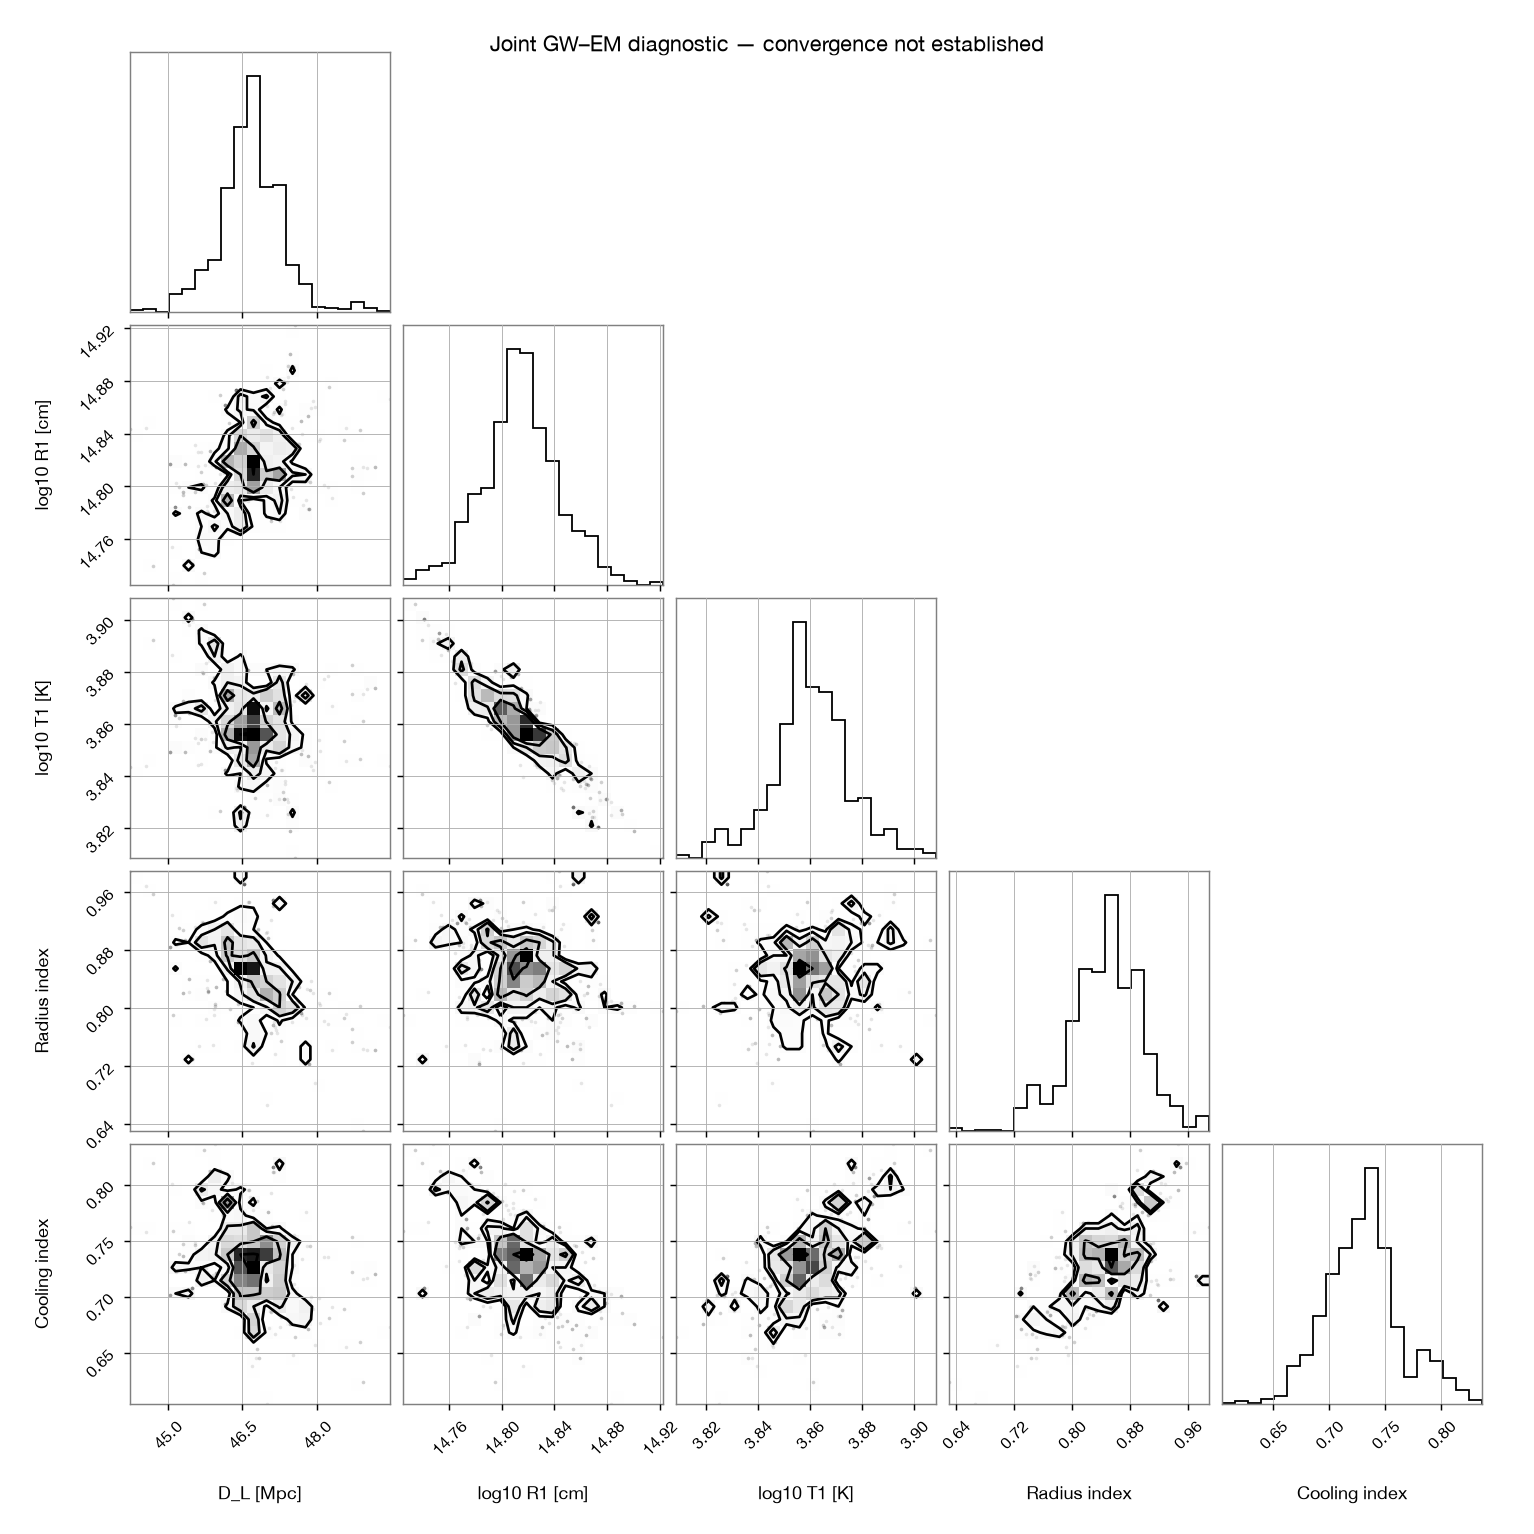

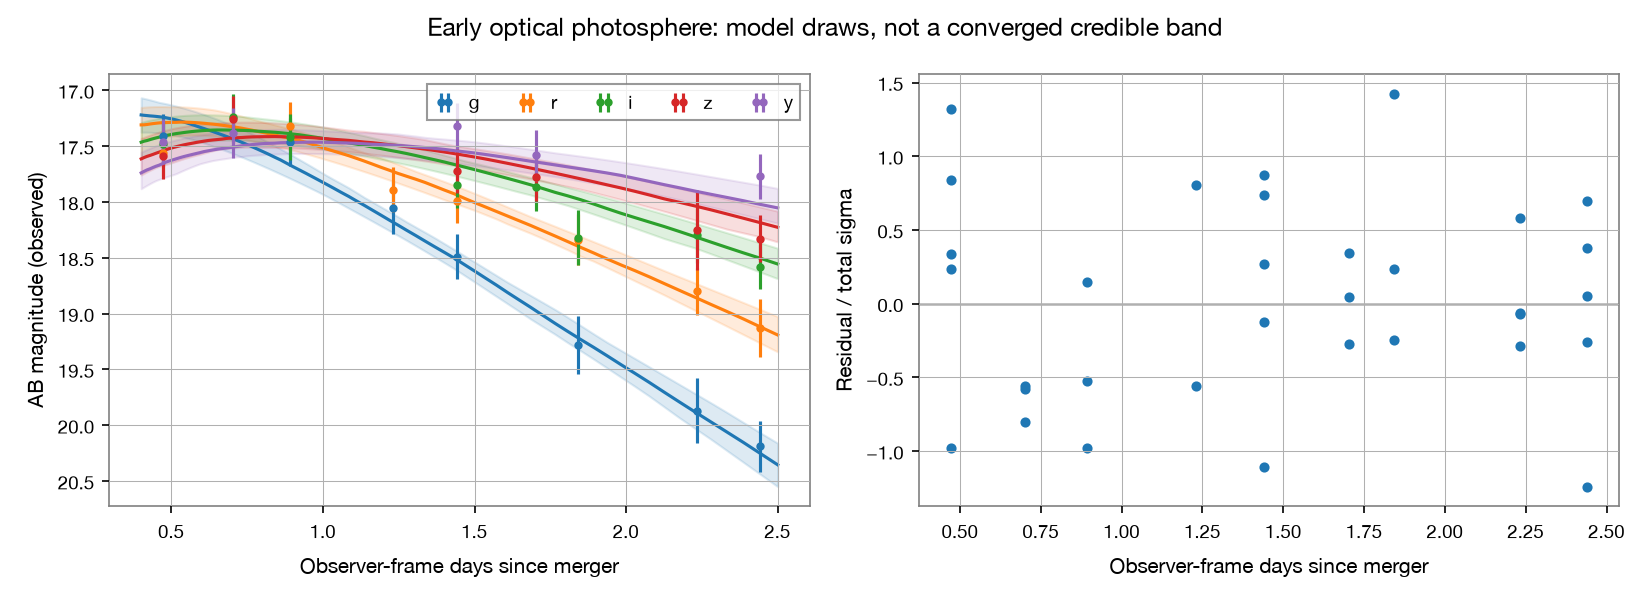

,5% diagnostic,50% diagnostic,95% diagnostic
chirp_mass,1.197404e+00,1.197441e+00,1.197476e+00
luminosity_distance,4.563669e+01,4.666714e+01,4.767093e+01
phase,2.429485e+00,2.477094e+00,2.523190e+00
geocent_time,1.187009e+09,1.187009e+09,1.187009e+09
log10_R1_cm,1.476718e+01,1.481401e+01,1.486652e+01
log10_T1_K,3.834608e+00,3.859501e+00,3.884727e+00
radius_index,7.518095e-01,8.500094e-01,9.190880e-01
cooling_index,6.752864e-01,7.311370e-01,7.941080e-01


In [18]:
joint_samples = None
if MODE == 'fast' and RUN_JOINT_PE:
    started = time.perf_counter()
    joint_like, joint_center, joint_samples = joint_pe.run_joint(
        like.gaussian, joint_pe.fast_priors(), theta_fit, JOINT_OUT,
        burn=JOINT_BURN, steps=JOINT_STEPS, seed=SEED+1, em=em_like)
    timings['joint_sampling_and_plots_seconds'] = time.perf_counter()-started
    # Save the GW data provenance next to the joint model/photometry manifest.
    (JOINT_OUT/'gw_manifest.json').write_text(json.dumps(metadata, indent=2))
    lg, le = joint_like.components(joint_center)
    assert np.allclose(joint_like(joint_center), lg+le)
    print('Initial log L_GW / log L_EM:', lg, le)
    print('Cold draws / dimensions:', joint_samples.shape)
    print(joint_pe.WARNING)
    display(Image(filename=str(JOINT_OUT/'joint_corner.png')))
    display(Image(filename=str(JOINT_OUT/'joint_lightcurve.png')))
    display(pd.DataFrame(json.loads((JOINT_OUT/'joint_quantiles.json').read_text())[
        'quantiles_5_50_95'], index=['5% diagnostic', '50% diagnostic', '95% diagnostic']).T)
else:
    print('Joint sampling skipped. Select MODE="fast" and RUN_JOINT_PE=True for a live run.')


### Inspect the joint chain and the distance–radius degeneracy

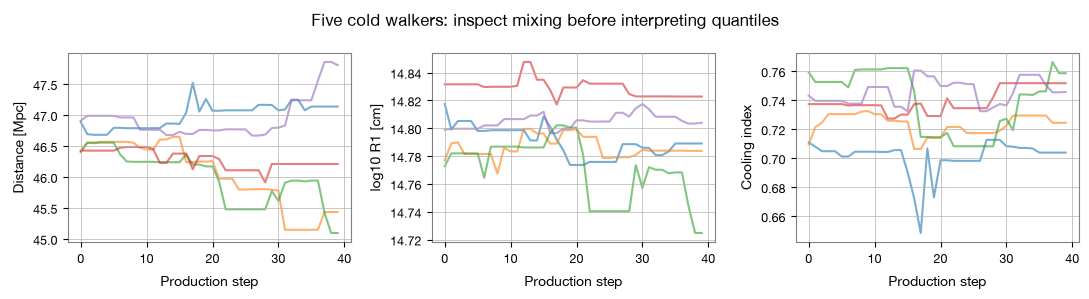

Chain too short for reliable autocorrelation time / ESS. Convergence NOT established.


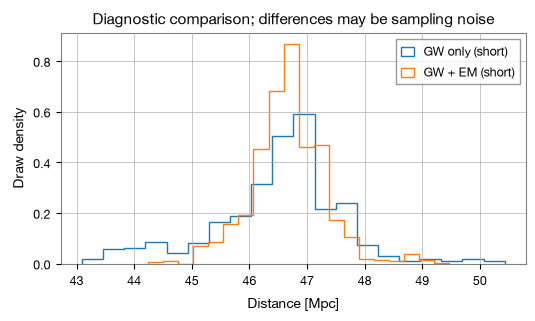

In [19]:
with plt.rc_context({'font.size':10, 'axes.labelsize':10, 'axes.titlesize':11,
                     'xtick.labelsize':9, 'ytick.labelsize':9, 'legend.fontsize':9,
                     'figure.titlesize':12}):
    if joint_samples is not None:
        from eryn.backends import HDFBackend
        from emcee.autocorr import integrated_time, AutocorrError
        joint_chain = HDFBackend(str(JOINT_OUT/'chains/joint_eryn.h5'), read_only=True).get_chain()['model_0'][:,0,:,0,:]
        fig, axes = plt.subplots(1,3,figsize=(11,3))
        for ax, column, label in zip(axes,[1,4,7],['Distance [Mpc]','log10 R1 [cm]','Cooling index']):
            ax.plot(joint_chain[:,:5,column],alpha=.6)
            ax.set(xlabel='Production step',ylabel=label)
        fig.suptitle('Five cold walkers: inspect mixing before interpreting quantiles')
        fig.tight_layout()
        plt.show()
        try:
            tau = integrated_time(joint_chain, quiet=False)
            print('Estimated autocorrelation times:', tau)
            print('Provisional ESS:', joint_chain.shape[0]*joint_chain.shape[1]/tau)
            print('An autocorrelation estimate alone is not proof of convergence.')
        except AutocorrError:
            print('Chain too short for reliable autocorrelation time / ESS. Convergence NOT established.')
        # Same fast GW priors, but both chains are short and locally initialized.
        gw_samples_path = FAST_OUT/'pilot_samples.npy'
        if RUN_FAST_SAMPLING and gw_samples_path.exists():
            gw_draws = np.load(gw_samples_path)
            fig,ax=plt.subplots(figsize=(6,3))
            ax.hist(gw_draws[:,1],bins=20,density=True,histtype='step',label='GW only (short)')
            ax.hist(joint_samples[:,1],bins=20,density=True,histtype='step',label='GW + EM (short)')
            ax.set(xlabel='Distance [Mpc]',ylabel='Draw density',title='Diagnostic comparison; differences may be sampling noise')
            ax.legend()
            plt.show()


### Optional longer joint run: 21 parameters

`--mode full` combines the 17-parameter GW configuration (256 s, 23–1024 Hz,
IMRPhenomPv2_NRTidal) with the same four photosphere parameters. The GW distance
prior becomes the full driver's volume prior; do not directly compare its
histogram to the fast conditional run. The association is assumed; no separate
host-position likelihood or population/selection factor is included.

The EM model remains approximate even when all GW parameters vary. This route
uses a local warm start, 64 walkers and four temperatures. Default 1000 burn-in
and 1000 production steps can take hours or longer and **do not guarantee
convergence or exploration of all modes**. Repeat with independent starts,
assess mixing/ESS, and test prior/model sensitivity before interpreting results.
The cell is disabled during normal Run All.

From the repository root:
```bash
# Fast joint sampling (real GW data + bundled EM data):
.venv/bin/python examples/real_event/gw170817_tutorial.py --mode fast --joint --sample
# Full GW+EM setup only, without starting the long sampler:
.venv/bin/python examples/real_event/gw170817_joint.py --mode full
# Explicit long run:
.venv/bin/python examples/real_event/gw170817_joint.py --mode full --sample --burn 1000 --steps 1000 --outdir results/joint_full_01
```
Use a new output directory for each independent run: rerunning the same output
path replaces that run's Eryn chain. Joint mode currently uses Gaussian GW noise.


In [20]:
full_joint_command = [sys.executable, str(EXAMPLES/'gw170817_joint.py'),
                      '--mode', 'full', '--sample', '--burn', str(FULL_BURN),
                      '--steps', str(FULL_STEPS), '--outdir', str(ROOT/'results/joint_full_01')]
if RUN_FULL_JOINT_PE:
    if (ROOT/'results/joint_full_01/chains/joint_eryn.h5').exists():
        raise FileExistsError('Choose a fresh output directory to preserve the previous joint run.')
    subprocess.run(full_joint_command, cwd=ROOT, check=True)
else:
    print('Long joint run disabled. Set RUN_FULL_JOINT_PE=True to launch it explicitly.')


Long joint run disabled. Set RUN_FULL_JOINT_PE=True to launch it explicitly.


## 12. Discussion exercises

1. Why is the fast SNR smaller? What information is lost when fmin increases?
2. How does a conditional likelihood slice differ from a marginalized posterior?
3. What happens to the distance posterior when inclination is allowed to vary?
4. Run fast sampling with more steps and different seeds. Which convergence
   diagnostics can you measure, and which questions remain unresolved by a short run?
5. Why can you not infer an EOS from fixed $\lambda_1=\lambda_2=400$ or the fast band?
6. Design a fair Gaussian–hyperbolic comparison: identical science priors and data,
   separate nuisance priors, convergence checks, cleaned/uncleaned releases and residuals.

## Scripts and sources

```bash
# From the repository root, in the same Python environment:
.venv/bin/python examples/real_event/gw170817_tutorial.py --mode preview
.venv/bin/python examples/real_event/gw170817_tutorial.py --mode fast --sample
.venv/bin/python examples/real_event/gw170817_tutorial.py --mode full
# Long run, only when explicitly selected:
.venv/bin/python examples/real_event/gw170817_tutorial.py --mode full --sample
```

- `gw170817_pilot.py`: data preparation, matched filtering, conditional likelihood and sampler.
- `gw170817_pe.py`: larger priors and full PE driver.
- `gw170817_tutorial.py`: common CLI for fast/preview/full.
- [HyperWave](https://github.com/asasli/HyperWave)
- [GWOSC event, cleaned-data notes and public PE sample links](https://gwosc.org/events/GW170817/)
- [Pinned cleaned v2 release](https://gwosc.org/eventapi/html/O1_O2-Preliminary/GW170817/v2/)
- [GWTC-1 documentation](https://gwosc.org/GWTC-1/)

**Delivered outputs:** the saved notebook outputs come from a real fast run.
Long full sampling has not been executed as part of this tutorial.

7. Compare the optical and near-infrared evolution. Why should the same decline model not be imposed on all bands and epochs?
8. Why must a flux upper limit not be treated as a Gaussian magnitude detection?
9. Which physical assumptions would allow a light curve to constrain distance or viewing angle jointly with GW data?
9. Double both radius and distance: why is the EM likelihood unchanged, while the GW likelihood changes?
10. Compare the joint fit with different time windows, dust assumptions and model-error floors. Which conclusions survive?
11. Why does sampling 21 parameters not turn the blackbody model into an ejecta/EOS model?
